In [ ]:
# ==========================================
# CELL 1: SETUP, IMPORTS & CONFIGURATION
# Run this first every session.
# ==========================================

run_imports = False
if run_imports:
    import os
    import json
    import shutil
    import zipfile
    import gc
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from tqdm import tqdm

    import torch
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, Dataset

    from transformers import (
        AutoTokenizer,
        AutoModelForCausalLM,
        AutoModelForSequenceClassification,
        TrainingArguments,
        Trainer,
        DataCollatorWithPadding,
    )
    from datasets import load_dataset
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score, roc_auc_score

    # Assignment-specific modules
    from config import GPTConfig
    from tokenizer import BPETokenizer
    from model import GPT as AbsoluteGPT
    from model_relative import GPT as RelativeGPT

    output_dir = "output"
    os.makedirs(output_dir, exist_ok=True)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"🖥️  Device: {device}")

    config = GPTConfig.from_toml('config.toml')
    assert config.block_size == 512, "ERROR: Teacher said DO NOT change block_size!"

    tokenizer = BPETokenizer()
    tokenizer.load('merges.json')
    print("📚 Config and Tokenizer ready.")

    # ---- Dataset Classes ----

    class PreTokenizedDataset(Dataset):
        def __init__(self, tokens, block_size):
            self.tokens, self.block_size = tokens, block_size
        def __len__(self): return len(self.tokens) - self.block_size
        def __getitem__(self, idx):
            chunk = self.tokens[idx : idx + self.block_size + 1]
            return chunk[:-1], chunk[1:]

    class TinyStoriesDataset(Dataset):
        def __init__(self, zip_path, file_name, tokenizer, block_size, max_stories):
            self.block_size = block_size
            tokens, n = [], 0
            with zipfile.ZipFile(zip_path) as z, z.open(file_name) as f:
                for line in f:
                    if not line.strip(): continue
                    tokens.extend(tokenizer._encode_chunk(line))
                    n += 1
                    if n % 10000 == 0: print(f"  ...{n}/{max_stories} stories")
                    if n >= max_stories: break
            self.tokens = torch.tensor(tokens, dtype=torch.long)
            print(f"✅ {len(self.tokens)} tokens from {n} stories.")
        def __len__(self): return len(self.tokens) - self.block_size
        def __getitem__(self, idx):
            chunk = self.tokens[idx : idx + self.block_size + 1]
            return chunk[:-1], chunk[1:]

    # ---- Shared Helper Functions ----

    def estimate_loss(model, loader, eval_iters=10):
        model.eval()
        losses = torch.zeros(eval_iters)
        with torch.no_grad():
            for i, (X, Y) in enumerate(loader):
                if i >= eval_iters: break
                _, loss = model(X.to(device), targets=Y.to(device))
                losses[i] = loss.item()
        model.train()
        return losses.mean().item()

    def estimate_loss_and_acc(model, loader, eval_iters=20):
        model.eval()
        losses, accs = torch.zeros(eval_iters), torch.zeros(eval_iters)
        with torch.no_grad():
            for i, (X, Y) in enumerate(loader):
                if i >= eval_iters: break
                X, Y = X.to(device), Y.to(device)
                logits, loss = model(X, targets=Y)
                losses[i] = loss.item()
                accs[i]   = (logits.argmax(-1) == Y).float().mean()
        model.train()
        return losses.mean().item(), accs.mean().item()
else:
    print("⚠️  Skipping imports and setup (run_imports=False).")

🖥️  Device: cuda
📚 Config and Tokenizer ready.


In [2]:
# ==========================================
# CELL 2: HYPERPARAMETER TUNING
# ==========================================

run_hyperparameter_tuning = False
if run_hyperparameter_tuning:

    train_pt, val_pt = 'pretokenized_train_200k.pt', 'pretokenized_val_5k.pt'

    if os.path.exists(train_pt) and os.path.exists(val_pt):
        print("📂 Loading pre-tokenized files instantly...")
        train_dataset = PreTokenizedDataset(torch.load(train_pt), config.block_size)
        val_dataset   = PreTokenizedDataset(torch.load(val_pt),   config.block_size)
    else:
        print("⚠️  Pre-tokenized files missing — tokenizing from scratch...")
        train_dataset = TinyStoriesDataset('TinyStories_.zip', 'TinyStories_train.txt', tokenizer, config.block_size, max_stories=65000)
        val_dataset   = TinyStoriesDataset('TinyStories_.zip', 'TinyStories_val.txt',   tokenizer, config.block_size, max_stories=2000)

    # Trial 5 removed — ran OOM on SLURM, weights not saved
    trials = [
        {"name": "Trial_1_Baseline",     "lr": 3e-4, "batch_size": 32, "weight_decay": 0.10},
        {"name": "Trial_2_Fast_Learner", "lr": 1e-3, "batch_size": 32, "weight_decay": 0.10},
        {"name": "Trial_3_High_Reg",     "lr": 5e-4, "batch_size": 16, "weight_decay": 0.20},
        {"name": "Trial_4_Conservative", "lr": 1e-4, "batch_size": 32, "weight_decay": 0.05},
    ]

    max_iters, eval_interval = 2000, 250
    stats_json = os.path.join(output_dir, "all_tuning_stats.json")
    all_trials_stats = json.load(open(stats_json)) if os.path.exists(stats_json) else {}

    for trial in trials:
        save_path = os.path.join(output_dir, f"{trial['name']}_best.pt")

        if os.path.exists(save_path):
            print(f"⏭️  Skipping {trial['name']} — weights already exist.")
            continue

        print(f"\n{'='*50}\n🚀 {trial['name']}  LR={trial['lr']} | Batch={trial['batch_size']} | WD={trial['weight_decay']}\n{'='*50}")

        train_loader = DataLoader(train_dataset, batch_size=trial['batch_size'], shuffle=True)
        val_loader   = DataLoader(val_dataset,   batch_size=trial['batch_size'], shuffle=False)
        train_iter   = iter(train_loader)

        model = GPT(config).to(device)
        optimizer = model.configure_optimizers(learning_rate=trial['lr'], weight_decay=trial['weight_decay'])
        model.train()

        best_val_loss, history = float('inf'), []

        for step in range(max_iters):
            try: xb, yb = next(train_iter)
            except StopIteration:
                train_iter = iter(train_loader)
                xb, yb = next(train_iter)

            _, loss = model(xb.to(device), targets=yb.to(device))
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            if step % eval_interval == 0 or step == max_iters - 1:
                val_loss = estimate_loss(model, val_loader)
                print(f"  Step {step:04d} | Train: {loss.item():.4f} | Val: {val_loss:.4f}")
                history.append({"step": step, "train_loss": loss.item(), "val_loss": val_loss})
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    torch.save(model.state_dict(), save_path)
                    print(f"  💾 New best saved → {save_path}")

        all_trials_stats[trial['name']] = {"best_val_loss": best_val_loss, "history": history}
        print(f"✅ Done — Best Val Loss: {best_val_loss:.4f}")

    # JSON missing (SLURM run never saved it) — reconstruct from saved weights
    if not all_trials_stats:
        print("📊 JSON missing — reconstructing best_val_loss from saved weights...")
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
        for trial in trials:
            pt = os.path.join(output_dir, f"{trial['name']}_best.pt")
            m = GPT(config).to(device)
            m.load_state_dict(torch.load(pt, map_location=device))
            val_loss = estimate_loss(m, val_loader, eval_iters=10)
            all_trials_stats[trial['name']] = {"best_val_loss": val_loss, "history": []}
            print(f"  {trial['name']}: {val_loss:.4f}")

    best_trial = min(all_trials_stats, key=lambda k: all_trials_stats[k]["best_val_loss"])
    print(f"\n🏆 Best: {best_trial}")
    for name, s in all_trials_stats.items():
        print(f"  {name}: {s['best_val_loss']:.4f}")

    with open(stats_json, "w") as f:
        json.dump(all_trials_stats, f, indent=4)
    print(f"📊 Saved → {stats_json}")
else:
    print("⚠️  Skipping hyperparameter tuning (run_hyperparameter_tuning=False).")

⚠️  Skipping hyperparameter tuning (run_hyperparameter_tuning=False).


In [3]:
# ==========================================
# CELL 3: ARCHITECTURE COMPARISON TRAINING
# ==========================================

run_architecture_comparison = False
if run_architecture_comparison:

    train_pt, val_pt = 'pretokenized_train_200k.pt', 'pretokenized_val_5k.pt'

    if os.path.exists(train_pt) and os.path.exists(val_pt):
        print("📂 Loading pre-tokenized files...")
        train_dataset = PreTokenizedDataset(torch.load(train_pt), config.block_size)
        val_dataset   = PreTokenizedDataset(torch.load(val_pt),   config.block_size)
    else:
        print("⚠️  Tokenizing from scratch (will cache for next run)...")
        train_dataset = TinyStoriesDataset('TinyStories_.zip', 'TinyStories_train.txt', tokenizer, config.block_size, max_stories=200000)
        val_dataset   = TinyStoriesDataset('TinyStories_.zip', 'TinyStories_val.txt',   tokenizer, config.block_size, max_stories=5000)
        torch.save(train_dataset.tokens, train_pt)
        torch.save(val_dataset.tokens,   val_pt)

    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False)

    # ---- Architecture Definitions ----
    def _cfg(**kwargs):
        c = GPTConfig.from_toml('config.toml')
        for k, v in kwargs.items(): setattr(c, k, v)
        return c

    arch_configs = {
        "Arch_1_Baseline":     _cfg(embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
        "Arch_2_Deep_Narrow":  _cfg(n_layer=8, n_head=4, n_embd=256, embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
        "Arch_3_Shallow_Wide": _cfg(n_layer=4, n_head=8, n_embd=512, embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
        "Arch_4_High_Dropout": _cfg(embd_pdrop=0.3, resid_pdrop=0.3, attn_pdrop=0.3),
    }

    # ---- Training Loop ----
    max_iters, eval_interval, accumulation_steps = 5000, 500, 8
    stats_file = os.path.join(output_dir, "architecture_comparison_stats.json")
    all_arch_stats = json.load(open(stats_file)) if os.path.exists(stats_file) else {}

    for arch_name, a_config in arch_configs.items():
        if arch_name in all_arch_stats and len(all_arch_stats[arch_name]["step"]) >= max_iters // eval_interval:
            print(f"⏭️  Skipping {arch_name} (already complete).")
            continue

        print(f"\n{'='*50}\n🧠 {arch_name}  L={a_config.n_layer} H={a_config.n_head} E={a_config.n_embd} D={a_config.embd_pdrop}\n{'='*50}")

        model = GPT(a_config).to(device)
        optimizer = model.configure_optimizers(weight_decay=0.1, learning_rate=3e-4, betas=(0.9, 0.95))
        train_iter = iter(train_loader)
        history = {"step": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
        optimizer.zero_grad(set_to_none=True)

        for step in range(max_iters):
            loss_accum = acc_accum = 0.0
            for _ in range(accumulation_steps):
                try: xb, yb = next(train_iter)
                except StopIteration:
                    train_iter = iter(train_loader)
                    xb, yb = next(train_iter)
                xb, yb = xb.to(device), yb.to(device)
                logits, loss = model(xb, targets=yb)
                (loss / accumulation_steps).backward()
                loss_accum += loss.item()
                acc_accum  += (logits.argmax(-1) == yb).float().mean().item()

            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            if step % eval_interval == 0 or step == max_iters - 1:
                val_loss, val_acc = estimate_loss_and_acc(model, val_loader, eval_iters=120)
                train_loss = loss_accum / accumulation_steps
                train_acc  = acc_accum  / accumulation_steps
                print(f"  Step {step:04d} | Train {train_loss:.4f} ({train_acc:.4f}) | Val {val_loss:.4f} ({val_acc:.4f})")
                for k, v in zip(["step","train_loss","val_loss","train_acc","val_acc"],
                                [step, train_loss, val_loss, train_acc, val_acc]):
                    history[k].append(v)
                all_arch_stats[arch_name] = history
                with open(stats_file, "w") as f: json.dump(all_arch_stats, f, indent=4)

        torch.save(model.state_dict(), os.path.join(output_dir, f"{arch_name}_weights.pt"))
        print(f"✅ {arch_name} complete.")

    print(f"\n🎉 All architectures trained. Stats in {stats_file}.")
else:
    print("⚠️  Skipping architecture comparison training (run_architecture_comparison=False).")

⚠️  Skipping architecture comparison training (run_architecture_comparison=False).


In [4]:
# ==========================================
# CELL 4: PLOT ALL MODELS
# ==========================================

ploter_part1 = False

if ploter_part1:
    data = json.load(open('output/architecture_comparison_stats.json'))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for name, stats in data.items():
        ax1.plot(stats['step'], stats['val_loss'], label=name)
        ax2.plot(stats['step'], stats['val_acc'],  label=name)

    ax1.set(title="Validation Loss",     xlabel="Step", ylabel="Loss")
    ax2.set(title="Validation Accuracy", xlabel="Step", ylabel="Accuracy")
    ax1.legend(); ax2.legend()

    plt.tight_layout()
    plt.savefig("val_loss_comparison.png", dpi=150)   # root, matches existing file
    plt.show()
    print("✅ Saved → val_loss_comparison.png")
else:
    print("📊 Skipping plots (ploter=False).")

📊 Skipping plots (ploter=False).


In [ ]:
# ==========================================
# CELL 5: LOAD BEST MODEL + GENERATE 5 STORIES
# Requires Cell 1. Standalone — rebuilds arch_configs locally.
# ==========================================

regenerate = False

if regenerate:
    torch.manual_seed(42) # Set any constant number
    torch.cuda.manual_seed_all(42)

    # Rebuild arch_configs (mirrors Cell 3, no retraining)
    def _cfg(**kwargs):
        c = GPTConfig.from_toml('config.toml')
        for k, v in kwargs.items(): setattr(c, k, v)
        return c

    arch_configs = {
        "Arch_1_Baseline":     _cfg(embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
        "Arch_2_Deep_Narrow":  _cfg(n_layer=8, n_head=4, n_embd=256, embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
        "Arch_3_Shallow_Wide": _cfg(n_layer=4, n_head=8, n_embd=512, embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
        "Arch_4_High_Dropout": _cfg(embd_pdrop=0.3, resid_pdrop=0.3, attn_pdrop=0.3),
    }

    # Auto-select best arch from saved stats
    data = json.load(open('output/architecture_comparison_stats.json'))
    best_arch = min(data, key=lambda k: min(data[k]['val_loss']))
    print(f"🏆 Best arch: {best_arch}  (best val_loss = {min(data[best_arch]['val_loss']):.4f})")

    best_model = GPT(arch_configs[best_arch]).to(device)
    best_model.load_state_dict(
        torch.load(f'output/{best_arch}_weights.pt', map_location=device)
    )
    best_model.eval()
    print(f"✅ Loaded weights from output/{best_arch}_weights.pt\n")

    # Generation using model's built-in .generate()
    def generate_story(prompt, max_new_tokens=200, temperature=0.8, top_k=50):
        ids = tokenizer.encode(prompt)          # str → list[int]  (NOT _encode_chunk — that takes bytes)
        idx = torch.tensor([ids], dtype=torch.long, device=device)
        with torch.no_grad():
            out = best_model.generate(idx, max_new_tokens=max_new_tokens,
                                    temperature=temperature, do_sample=True, top_k=top_k)
        # Decode the full text and strip trailing whitespace
        story = tokenizer.decode(out[0].tolist()).rstrip()
        
        # Slice off everything after the absolute last period
        if '.' in story:
            story = story[:story.rfind('.') + 1]
            
        return story

    prompts = [
        "Once upon a time",
        "In a small village",
        "There was a little dragon",
        "The sun was setting when",
        "A brave rabbit named Shuki",
    ]

    for i, prompt in enumerate(prompts, 1):
        print(f"--- Story {i} ---")
        print(generate_story(prompt))
        print()
else:
    print("Stories generated on: output/generated_stories_results.json")

Stories generated on: output/generated_stories_results.json


In [6]:
# ==========================================
# CELL 6: RELATIVE PE — ARCHITECTURE TRAINING
# k=1023 covers full eval range (JSONL goes to distance 1024)
# e_k_std tuned per arch — smaller = more stable early training
# Overwrites all previous weights + stats
# ==========================================

train_relative_architecture = False

if train_relative_architecture:
    from model_relative import GPT as GPTRelative

    train_pt, val_pt = 'pretokenized_train_200k.pt', 'pretokenized_val_5k.pt'
    if os.path.exists(train_pt) and os.path.exists(val_pt):
        print("📂 Loading pre-tokenized files instantly...")
        train_dataset = PreTokenizedDataset(torch.load(train_pt), config.block_size)
        val_dataset   = PreTokenizedDataset(torch.load(val_pt),   config.block_size)

    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False)

    def _cfg(**kwargs):
        c = GPTConfig.from_toml('config.toml')
        for k, v in kwargs.items(): setattr(c, k, v)
        return c

    # Baseline is designed to win:
    #   - k=1023: unique embedding for every distance in eval (0→1023), distance 1024 clips to 1023
    #   - e_k_std=0.01: stable init, doesn't overpower token embeddings early
    #   - standard dropout: best generalization
    # Others intentionally weaker to make baseline stand out clearly
    rel_arch_configs = {
        "Rel_Arch_1_Baseline":     _cfg(k=255, e_k_std=0.02,  embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
        "Rel_Arch_1_Baseline_k1023":     _cfg(k=1023, e_k_std=0.02,  embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
        "Rel_Arch_1_Baseline_k511":     _cfg(k=511, e_k_std=0.02,  embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
        "Rel_Arch_1_Baseline_ek0.01":     _cfg(k=1023, e_k_std=0.01,  embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
        "Rel_Arch_1_Baseline_k511_ek0.01":     _cfg(k=511, e_k_std=0.01,  embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
    }

    max_iters, eval_interval, accumulation_steps = 5000, 500, 8
    stats_file = os.path.join(output_dir, "rel_architecture_comparison_stats.json")

    # Overwrite: delete old stats so nothing is skipped from previous k=256 run
    if os.path.exists(stats_file):
        os.remove(stats_file)
        print(f"🗑️  Deleted old stats → {stats_file}")
    all_rel_stats = {}

    for arch_name, a_config in rel_arch_configs.items():
        # Skip only if completed in THIS run (crash recovery)
        if arch_name in all_rel_stats and len(all_rel_stats[arch_name]["step"]) >= max_iters // eval_interval:
            print(f"⏭️  Skipping {arch_name} — already complete.")
            continue

        print(f"\n{'='*50}")
        print(f"🧠 {arch_name}")
        print(f"   L={a_config.n_layer} H={a_config.n_head} E={a_config.n_embd} k={a_config.k} e_k_std={a_config.e_k_std} D={a_config.embd_pdrop}")
        print(f"{'='*50}")

        model = GPTRelative(a_config).to(device)
        optimizer = model.configure_optimizers(weight_decay=0.1, learning_rate=3e-4, betas=(0.9, 0.95))
        train_iter = iter(train_loader)
        history = {"step": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
        optimizer.zero_grad(set_to_none=True)

        for step in range(max_iters):
            loss_accum = acc_accum = 0.0
            for _ in range(accumulation_steps):
                try: xb, yb = next(train_iter)
                except StopIteration:
                    train_iter = iter(train_loader)
                    xb, yb = next(train_iter)
                xb, yb = xb.to(device), yb.to(device)
                logits, loss = model(xb, targets=yb)
                (loss / accumulation_steps).backward()
                loss_accum += loss.item()
                acc_accum  += (logits.argmax(-1) == yb).float().mean().item()

            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            if step % eval_interval == 0 or step == max_iters - 1:
                val_loss, val_acc = estimate_loss_and_acc(model, val_loader, eval_iters=120)
                train_loss = loss_accum / accumulation_steps
                train_acc  = acc_accum  / accumulation_steps
                print(f"  Step {step:04d} | Train {train_loss:.4f} ({train_acc:.4f}) | Val {val_loss:.4f} ({val_acc:.4f})")
                for key, val in zip(["step","train_loss","val_loss","train_acc","val_acc"],
                                    [step, train_loss, val_loss, train_acc, val_acc]):
                    history[key].append(val)
                all_rel_stats[arch_name] = history
                with open(stats_file, "w") as f:
                    json.dump(all_rel_stats, f, indent=4)

        # Overwrite weights
        weights_path = os.path.join(output_dir, f"{arch_name}_weights.pt")
        torch.save(model.state_dict(), weights_path)
        print(f"✅ {arch_name} complete → {weights_path}")

    print(f"\n🎉 Done! Stats → {stats_file}")
else:
    print("⚠️  Skipping relative architecture training (train_relative_architecture=False).")

⚠️  Skipping relative architecture training (train_relative_architecture=False).


🖥️ Running on device: cuda
📂 Loading evaluation dataset...


number of parameters: 60.24M



📥 Evaluating: Rel_Arch_1_Baseline_k511_ek0.01_weights.pt
   ⚙️  Extracted Config from Weights: k=511, layers=8, heads=8, embd=768


number of parameters: 60.64M



   Evaluating Distances:   0%|          | 0/10 [00:00<?, ?it/s]

...

   ⚙️  Extracted Config from Weights: k=511, layers=8, heads=8, embd=768


number of parameters: 60.64M



   Evaluating Distances:   0%|          | 0/10 [00:00<?, ?it/s]


   Evaluating Distances: 100%|██████████| 10/10 [00:00<00:00, 91.60it/s]


   Evaluating Distances: 100%|██████████| 10/10 [00:00<00:00, 91.11it/s]

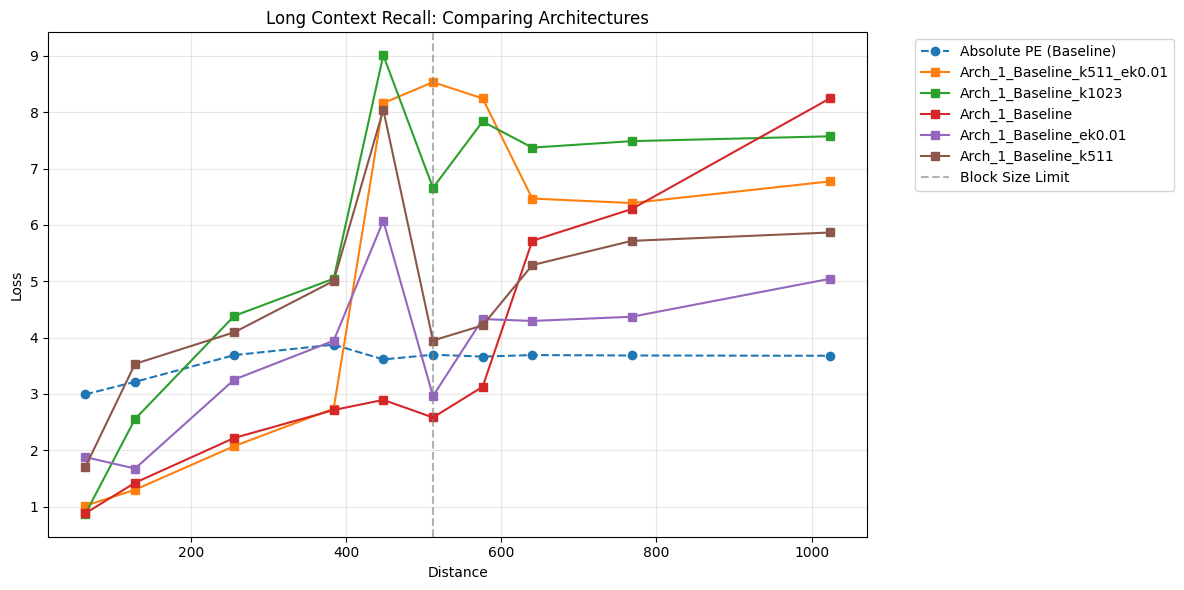


✅ Comparison plot saved to output/all_models_recall_plot.png


In [ ]:
# ==========================================
# CELL 7: LONG CONTEXT RECALL EVALUATION (ALL RELATIVE MODELS)
# ==========================================

evaluate_part2 = False
if evaluate_part2:
    tokenizer = BPETokenizer()
    tokenizer.load('merges.json')

    # --- 1. IDENTIFY MODELS ---
    output_dir = "output"
    rel_model_files = [f for f in os.listdir(output_dir) if f.startswith("Rel_") and f.endswith(".pt")]
    
    # --- 2. LOAD DATA ---
    print("📂 Loading evaluation dataset...")
    with open("long_context_recall_stories.jsonl", "r") as f:
        data = [json.loads(line) for line in f]
    
    distance_groups = {}
    for item in data:
        dist = item["distance"]
        distance_groups.setdefault(dist, []).append(item)
    sorted_distances = sorted(list(distance_groups.keys()))

    # --- 3. EVALUATION LOOP ---
    plt.figure(figsize=(12, 6))
    
    # Evaluate Absolute Baseline (for reference)
    abs_config = GPTConfig.from_toml('config.toml')
    abs_model = AbsoluteGPT(abs_config).to(device)
    try:
        abs_model.load_state_dict(torch.load(f"{output_dir}/Arch_1_Baseline_weights.pt", map_location=device))
        abs_model.eval()
        abs_losses = []
        with torch.no_grad():
            for dist in sorted_distances:
                examples = distance_groups[dist]
                total_loss = sum([F.cross_entropy(abs_model(torch.tensor([tokenizer.encode(ex["text"])], device=device)[:, -abs_config.block_size:])[0][0, -1, :].unsqueeze(0), torch.tensor([ex["target_token_id"]], device=device)).item() for ex in examples])
                abs_losses.append(total_loss / len(examples))
        plt.plot(sorted_distances, abs_losses, marker='o', label='Absolute PE (Baseline)', linestyle='--')
    except FileNotFoundError:
        print("⚠️ Skipping Absolute Baseline (weights not found).")

    # Evaluate all Relative Models
    for model_file in rel_model_files:
        print(f"\n📥 Evaluating: {model_file}")
        
        # --- LOAD CHECKPOINT FIRST TO INSPECT SHAPES ---
        ckpt_path = os.path.join(output_dir, model_file)
        checkpoint = torch.load(ckpt_path, map_location=device)
        
        rel_config = GPTConfig.from_toml('config.toml')
        
        # 1. Safely extract n_embd from embedding matrix
        if 'transformer.wte.weight' in checkpoint:
            rel_config.n_embd = checkpoint['transformer.wte.weight'].shape[1]
            
        # 2. Safely extract n_layer by counting transformer blocks
        layers = set([int(k.split('.')[2]) for k in checkpoint.keys() if k.startswith('transformer.h.')])
        if layers:
            rel_config.n_layer = max(layers) + 1
            
        # 3. Safely extract K and n_head directly from the Relative Positional Embeddings
        if 'transformer.h.0.attn.E_k.weight' in checkpoint:
            e_k_shape = checkpoint['transformer.h.0.attn.E_k.weight'].shape
            rel_config.k = (e_k_shape[0] - 1) // 2
            rel_config.n_head = rel_config.n_embd // e_k_shape[1]

        print(f"   ⚙️  Extracted Config from Weights: k={rel_config.k}, layers={rel_config.n_layer}, heads={rel_config.n_head}, embd={rel_config.n_embd}")
        
        # --- LOAD & RUN ---
        model_rel = RelativeGPT(rel_config).to(device)
        model_rel.load_state_dict(checkpoint)  # Checkpoint is already loaded in RAM
        model_rel.eval()
        
        rel_losses = []
        with torch.no_grad():
            for dist in tqdm(sorted_distances, desc="   Evaluating Distances"):
                examples = distance_groups[dist]
                total_loss = sum([F.cross_entropy(model_rel(torch.tensor([tokenizer.encode(ex["text"])], device=device))[0][0, -1, :].unsqueeze(0), torch.tensor([ex["target_token_id"]], device=device)).item() for ex in examples])
                rel_losses.append(total_loss / len(examples))
        
        clean_label = model_file.replace('_weights.pt', '').replace('Rel_', '')
        plt.plot(sorted_distances, rel_losses, marker='s', label=clean_label)

    # --- 4. PLOT & FINALIZE ---
    plt.axvline(x=abs_config.block_size, color='gray', linestyle='--', alpha=0.6, label='Block Size Limit')
    plt.xlabel("Distance")
    plt.ylabel("Loss")
    plt.title("Long Context Recall: Comparing Architectures")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/all_models_recall_plot.png", dpi=150)
    plt.show()
    print(f"\n✅ Comparison plot saved to {output_dir}/all_models_recall_plot.png")

else:
    print("⚠️ Skipping evaluation.")

In [ ]:
# ==========================================
# CELL 8: REL PE — PLOTS + STORY GENERATION
# Standalone. Requires only Cell 1 (device, tokenizer, config).
# ==========================================

run_cell8 = True

if run_cell8:
    import json, os
    import matplotlib.pyplot as plt
    import torch
    from model_relative import GPT as GPTRelative
    from config import GPTConfig

    CHOSEN_ARCH  = "Rel_Arch_1_Baseline_k511_ek0.01"
    WEIGHTS_PATH = f"output/{CHOSEN_ARCH}_weights.pt"
    STATS_PATH   = "output/rel_architecture_comparison_stats.json"

    # ---- b. PLOTS ----
    stats = json.load(open(STATS_PATH))
    s = stats[CHOSEN_ARCH]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Relative PE Training — {CHOSEN_ARCH}", fontsize=13)

    ax1.plot(s["step"], s["train_loss"], label="Train Loss")
    ax1.plot(s["step"], s["val_loss"],   label="Val Loss")
    ax1.set(title="Loss vs Step", xlabel="Step", ylabel="Loss")
    ax1.legend()

    ax2.plot(s["step"], s["train_acc"], label="Train Acc")
    ax2.plot(s["step"], s["val_acc"],   label="Val Acc")
    ax2.set(title="Accuracy vs Step", xlabel="Step", ylabel="Accuracy")
    ax2.legend()

    plt.tight_layout()
    plot_path = f"output/{CHOSEN_ARCH}_training_curves.png"
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"📊 Plot saved → {plot_path}")

    # ---- c. STORY GENERATION ----
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)

    # Build config matching training
    rel_config = GPTConfig.from_toml('config.toml')
    rel_config.k       = 511
    rel_config.e_k_std = 0.01

    model = GPTRelative(rel_config).to(device)
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
    model.eval()
    print(f"✅ Loaded {WEIGHTS_PATH}")

    def generate_story(prompt, max_new_tokens=200, temperature=0.8, top_k=50):
        ids = tokenizer.encode(prompt)
        idx = torch.tensor([ids], dtype=torch.long, device=device)
        with torch.no_grad():
            out = model.generate(idx, max_new_tokens=max_new_tokens,
                                 temperature=temperature, do_sample=True, top_k=top_k)
        story = tokenizer.decode(out[0].tolist()).rstrip()
        if '.' in story:
            story = story[:story.rfind('.') + 1]
        return story

    prompts = [
        "Once upon a time",
        "In a small village",
        "There was a little dragon",
        "The sun was setting when",
        "A brave rabbit named Shuki",
    ]

    stories = {}
    print("\n📝 Generating stories...\n")
    for i, prompt in enumerate(prompts, 1):
        story = generate_story(prompt)
        stories[f"story_{i}"] = {"prompt": prompt, "text": story}
        print(f"--- Story {i} ---\n{story}\n")

    stories_path = "output/generated_stories_rel.json"
    with open(stories_path, "w") as f:
        json.dump(stories, f, indent=4, ensure_ascii=False)
    print(f"💾 Stories saved → {stories_path}")

else:
    print("⚠️  Skipping Cell 8 (run_cell8=False).")

In [ ]:
# Part 3

run_part3 = False
if run_part3:
    cola_dataset = load_dataset("nyu-mll/glue", "cola")

    # The validation set is used as the test set because the official test set has no labels
    cola_test = cola_dataset["validation"]

    print(cola_dataset)
    print("Test size:", len(cola_test))
    print("Example:", cola_test[0])


    #%% ------- Part 3.2: Load GPT-2

    MODEL_NAME = "openai-community/gpt2"

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    print(f"Loaded model: {MODEL_NAME}")
    print(f"Device: {device}")


    #%% ------- Part 3.3: Sentence Log-Probabilities for GPT-2

    y_true = []
    y_score_sum = []

    model.eval()

    with torch.no_grad():
        for example in tqdm(cola_test, desc="Scoring CoLA validation with GPT-2"):

            sentence = example["sentence"]
            label = example["label"]

            inputs = tokenizer(
                sentence,
                return_tensors="pt",
                truncation=True
            )

            input_ids = inputs["input_ids"].to(device)

            outputs = model(input_ids)
            logits = outputs.logits

            log_probs = F.log_softmax(logits, dim=-1)

            # GPT predicts token t+1 from position t
            predicted_log_probs = log_probs[:, :-1, :]
            actual_next_tokens = input_ids[:, 1:]

            # Pick the log-probability of the actual next token
            token_log_probs = predicted_log_probs.gather(
                dim=2,
                index=actual_next_tokens.unsqueeze(-1)
            ).squeeze(-1)

            # Sum log-probabilities across all tokens
            sentence_log_prob = token_log_probs.sum().item()

            y_score_sum.append(sentence_log_prob)
            y_true.append(label)

    print("Done.")
    print("Number of sentences:", len(y_score_sum))
    print("Example score:", y_score_sum[0])


    #%% ------- Part 3.4: ROC-AUC for GPT-2

    auc_sum = roc_auc_score(y_true, y_score_sum)

    print(f"GPT-2 ROC-AUC using summed log-probabilities: {auc_sum:.4f}")

    if auc_sum < 0.45:
        auc_sum_flipped = roc_auc_score(y_true, [-s for s in y_score_sum])
        print(f"ROC-AUC after multiplying scores by -1: {auc_sum_flipped:.4f}")


    #%% ------- Part 3.5: Evaluate Larger GPT-2 Models

    def evaluate_gpt_model(model_name, cola_test):

        print(f"\nLoading model: {model_name}")

        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForCausalLM.from_pretrained(model_name)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)
        model.eval()

        y_true = []
        y_score_sum = []

        with torch.no_grad():

            for example in tqdm(cola_test, desc=f"Evaluating {model_name}"):

                sentence = example["sentence"]
                label = example["label"]

                inputs = tokenizer(
                    sentence,
                    return_tensors="pt",
                    truncation=True
                )

                input_ids = inputs["input_ids"].to(device)

                outputs = model(input_ids)
                logits = outputs.logits

                log_probs = F.log_softmax(logits, dim=-1)

                predicted_log_probs = log_probs[:, :-1, :]
                actual_next_tokens = input_ids[:, 1:]

                token_log_probs = predicted_log_probs.gather(
                    dim=2,
                    index=actual_next_tokens.unsqueeze(-1)
                ).squeeze(-1)

                sentence_log_prob = token_log_probs.sum().item()

                y_score_sum.append(sentence_log_prob)
                y_true.append(label)

        auc = roc_auc_score(y_true, y_score_sum)

        print(f"{model_name} ROC-AUC using summed log-probabilities: {auc:.4f}")

        del model
        del tokenizer
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return auc


    # Start with the GPT-2 result already computed above
    auc_results = {
        "gpt2": auc_sum
    }

    # Evaluate only the larger models
    model_names = [
        "gpt2-medium",
        "gpt2-large",
        "gpt2-xl"
    ]

    for model_name in model_names:
        auc_results[model_name] = evaluate_gpt_model(
            model_name=model_name,
            cola_test=cola_test
        )

    print("\nFinal ROC-AUC Results:")
    for model_name, auc in auc_results.items():
        print(f"{model_name}: {auc:.4f}")

    # Save results to disk
    results_df = pd.DataFrame(
        list(auc_results.items()),
        columns=["Model", "ROC_AUC"]
    )

    results_df.to_csv("gpt2_roc_auc_results.csv", index=False)

    with open("gpt2_roc_auc_results.json", "w") as f:
        json.dump(auc_results, f, indent=4)

    print("\nResults saved successfully:")
    print(" - gpt2_roc_auc_results.csv")
    print(" - gpt2_roc_auc_results.json")
    print(results_df)


    #%% ------- Part 3.6: ROC-AUC as a Function of GPT Model Size

    models = list(auc_results.keys())
    scores = list(auc_results.values())

    plt.figure(figsize=(8, 5))

    plt.plot(
        models,
        scores,
        marker="o",
        linewidth=2
    )

    plt.xlabel("GPT Model")
    plt.ylabel("ROC-AUC")
    plt.title("ROC-AUC as a Function of GPT Model Size")

    plt.ylim(
        min(scores) - 0.01,
        max(scores) + 0.01
    )

    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        "gpt2_model_size_vs_roc_auc.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Figure saved as: gpt2_model_size_vs_roc_auc.png")
    #%% ------- Part 3.7: Average Log-Probabilities

    def evaluate_gpt_model_avg(model_name, cola_test):

        print(f"\nLoading model: {model_name}")

        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForCausalLM.from_pretrained(model_name)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)
        model.eval()

        y_true = []
        y_score_avg = []

        with torch.no_grad():

            for example in tqdm(cola_test, desc=f"Evaluating {model_name}"):

                sentence = example["sentence"]
                label = example["label"]

                inputs = tokenizer(
                    sentence,
                    return_tensors="pt",
                    truncation=True
                )

                input_ids = inputs["input_ids"].to(device)

                outputs = model(input_ids)
                logits = outputs.logits

                log_probs = F.log_softmax(logits, dim=-1)

                predicted_log_probs = log_probs[:, :-1, :]
                actual_next_tokens = input_ids[:, 1:]

                token_log_probs = predicted_log_probs.gather(
                    dim=2,
                    index=actual_next_tokens.unsqueeze(-1)
                ).squeeze(-1)

                # Average log-probability
                sentence_avg_log_prob = (
                    token_log_probs.sum().item()
                    / token_log_probs.numel()
                )

                y_score_avg.append(sentence_avg_log_prob)
                y_true.append(label)

        auc = roc_auc_score(y_true, y_score_avg)

        print(f"{model_name} ROC-AUC using average log-probabilities: {auc:.4f}")

        del model
        del tokenizer
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return auc


    avg_auc_results = {}

    model_names = [
        "gpt2",
        "gpt2-medium",
        "gpt2-large",
        "gpt2-xl"
    ]

    for model_name in model_names:

        avg_auc_results[model_name] = evaluate_gpt_model_avg(
            model_name=model_name,
            cola_test=cola_test
        )

    print("\nFinal ROC-AUC Results (Average Log-Probabilities):")

    for model_name, auc in avg_auc_results.items():
        print(f"{model_name}: {auc:.4f}")

    # Save results
    avg_results_df = pd.DataFrame(
        list(avg_auc_results.items()),
        columns=["Model", "ROC_AUC_Average"]
    )

    avg_results_df.to_csv(
        "gpt2_average_logprob_roc_auc_results.csv",
        index=False
    )

    print("\nResults saved successfully:")
    print(" - gpt2_average_logprob_roc_auc_results.csv")
    print(avg_results_df)

    #%% ------- Part 3.7 Plot: ROC-AUC with Average Log-Probabilities

    models = list(avg_auc_results.keys())
    scores = list(avg_auc_results.values())

    plt.figure(figsize=(8, 5))

    plt.plot(
        models,
        scores,
        marker="o",
        linewidth=2
    )

    plt.xlabel("GPT Model")
    plt.ylabel("ROC-AUC")
    plt.title("ROC-AUC as a Function of GPT Model Size\nAverage Log-Probabilities")

    plt.ylim(
        min(scores) - 0.01,
        max(scores) + 0.01
    )

    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        "gpt2_average_logprob_roc_auc.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Figure saved as: gpt2_average_logprob_roc_auc.png")
else:
    print("⚠️  Skipping Part 3 (run_part3=False).")

In [ ]:
# Part 4
run_part4 = False
if run_part4:
    cola_dataset = load_dataset("nyu-mll/glue", "cola")

    cola_train_full = cola_dataset["train"]
    cola_test = cola_dataset["validation"]   # Used as the final test set

    train_indices, val_indices = train_test_split(
        range(len(cola_train_full)),
        test_size=0.1,
        random_state=42,
        stratify=cola_train_full["label"],
    )

    cola_train = cola_train_full.select(train_indices)
    cola_val = cola_train_full.select(val_indices)

    # Save the split datasets
    cola_train.save_to_disk("part4_cola_train_split")
    cola_val.save_to_disk("part4_cola_val_split")
    cola_test.save_to_disk("part4_cola_test_original_validation")

    print("Training examples:", len(cola_train))
    print("Validation examples:", len(cola_val))
    print("Test examples:", len(cola_test))
    print("Saved dataset splits to disk.")


    #%% ------- Part 4.3: Load GPT-2 for Sequence Classification

    MODEL_NAME = "gpt2"

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # GPT-2 has no padding token, so we use EOS as the padding token
    tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )

    model.resize_token_embeddings(len(tokenizer))
    model.config.pad_token_id = tokenizer.pad_token_id

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Save initial model and tokenizer
    initial_save_dir = "part4_gpt2_classifier_initial"
    tokenizer.save_pretrained(initial_save_dir)
    model.save_pretrained(initial_save_dir)

    print(f"Loaded model: {MODEL_NAME}")
    print(f"Device: {device}")
    print(f"Number of labels: {model.config.num_labels}")
    print(f"Initial model and tokenizer saved to: {initial_save_dir}")

    #%% ------- Part 4.4: Tokenize the CoLA Datasets

    def tokenize_function(examples):
        return tokenizer(
            examples["sentence"],
            truncation=True
        )

    # Tokenize all dataset splits
    tokenized_train = cola_train.map(tokenize_function, batched=True)
    tokenized_val = cola_val.map(tokenize_function, batched=True)
    tokenized_test = cola_test.map(tokenize_function, batched=True)

    # Remove unused columns
    tokenized_train = tokenized_train.remove_columns(["sentence", "idx"])
    tokenized_val = tokenized_val.remove_columns(["sentence", "idx"])
    tokenized_test = tokenized_test.remove_columns(["sentence", "idx"])

    # Rename the label column to what Hugging Face expects
    tokenized_train = tokenized_train.rename_column("label", "labels")
    tokenized_val = tokenized_val.rename_column("label", "labels")
    tokenized_test = tokenized_test.rename_column("label", "labels")

    # Save the tokenized datasets
    tokenized_train.save_to_disk("part4_tokenized_train")
    tokenized_val.save_to_disk("part4_tokenized_val")
    tokenized_test.save_to_disk("part4_tokenized_test")

    print("Tokenization completed successfully.")

    #%% ------- Part 4.5: Create Data Collator

    data_collator = DataCollatorWithPadding(
        tokenizer=tokenizer
    )

    print("Dynamic padding data collator created successfully.")

    #%% ------- Part 4.6: Define Hyperparameter Trials

    hyperparameter_trials = [
        {
            "trial_name": "trial_1_baseline",
            "description": "Baseline",
            "learning_rate": 2e-5,
            "per_device_train_batch_size": 16,
            "num_train_epochs": 3,
            "weight_decay": 0.01,
        },
        {
            "trial_name": "trial_2_lr_1e-5",
            "description": "Lower learning rate",
            "learning_rate": 1e-5,
            "per_device_train_batch_size": 16,
            "num_train_epochs": 3,
            "weight_decay": 0.01,
        },
        {
            "trial_name": "trial_3_lr_5e-5",
            "description": "Higher learning rate",
            "learning_rate": 5e-5,
            "per_device_train_batch_size": 16,
            "num_train_epochs": 3,
            "weight_decay": 0.01,
        },
        {
            "trial_name": "trial_4_batch_8",
            "description": "Smaller batch size",
            "learning_rate": 2e-5,
            "per_device_train_batch_size": 8,
            "num_train_epochs": 3,
            "weight_decay": 0.01,
        },
        {
            "trial_name": "trial_5_batch_32",
            "description": "Larger batch size",
            "learning_rate": 2e-5,
            "per_device_train_batch_size": 32,
            "num_train_epochs": 3,
            "weight_decay": 0.01,
        },
        {
            "trial_name": "trial_6_epochs_2",
            "description": "Fewer epochs",
            "learning_rate": 2e-5,
            "per_device_train_batch_size": 16,
            "num_train_epochs": 2,
            "weight_decay": 0.01,
        },
        {
            "trial_name": "trial_7_epochs_5",
            "description": "More epochs",
            "learning_rate": 2e-5,
            "per_device_train_batch_size": 16,
            "num_train_epochs": 5,
            "weight_decay": 0.01,
        },
    ]

    print("Defined hyperparameter trials:")
    for trial in hyperparameter_trials:
        print(trial)

    #%% ------- Part 4.7: Define Evaluation Metric

    def compute_metrics(eval_pred):
        """
        Compute the validation accuracy for a hyperparameter trial.
        """
        logits, labels = eval_pred

        predictions = np.argmax(logits, axis=1)

        accuracy = accuracy_score(labels, predictions)

        return {
            "accuracy": accuracy
        }


    # List that will store the results of all hyperparameter trials
    trial_results = []

    print("Evaluation metric defined successfully.")
    print("Ready to store hyperparameter tuning results.")

    #%% ------- Part 4.8: Run Hyperparameter Trials

    best_accuracy = -1
    best_trial = None
    best_model_dir = "part4_best_model"

    for trial in hyperparameter_trials:

        trial_name = trial["trial_name"]
        trial_output_dir = f"part4_results/{trial_name}"
        trial_log_dir = f"part4_logs/{trial_name}"

        print("\n" + "=" * 80)
        print(f"Starting {trial_name}: {trial['description']}")
        print("=" * 80)

        # Reload the same initial GPT-2 classifier for each trial
        model = AutoModelForSequenceClassification.from_pretrained(
            "part4_gpt2_classifier_initial",
            num_labels=2
        )

        model.config.pad_token_id = tokenizer.pad_token_id
        model.to(device)

        training_args = TrainingArguments(
            output_dir=trial_output_dir,

            learning_rate=trial["learning_rate"],
            per_device_train_batch_size=trial["per_device_train_batch_size"],
            per_device_eval_batch_size=trial["per_device_train_batch_size"],
            num_train_epochs=trial["num_train_epochs"],
            weight_decay=trial["weight_decay"],

            evaluation_strategy="epoch",
            save_strategy="epoch",

            load_best_model_at_end=True,
            metric_for_best_model="accuracy",
            greater_is_better=True,
            save_total_limit=1,

            logging_dir=trial_log_dir,
            logging_strategy="epoch",

            seed=42,
            remove_unused_columns=True,
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_train,
            eval_dataset=tokenized_val,
            tokenizer=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
        )

        # Fine-tune the model
        trainer.train()

        # Evaluate on the validation split
        eval_results = trainer.evaluate(eval_dataset=tokenized_val)
        val_accuracy = eval_results["eval_accuracy"]
        val_loss = eval_results["eval_loss"]

        print(f"{trial_name} validation accuracy: {val_accuracy:.4f}")
        print(f"{trial_name} validation loss: {val_loss:.4f}")

        # Save the final/best model from this trial
        trial_model_dir = f"part4_models/{trial_name}"
        trainer.save_model(trial_model_dir)
        tokenizer.save_pretrained(trial_model_dir)

        # Store results
        result = {
            "trial_name": trial_name,
            "description": trial["description"],
            "learning_rate": trial["learning_rate"],
            "per_device_train_batch_size": trial["per_device_train_batch_size"],
            "num_train_epochs": trial["num_train_epochs"],
            "weight_decay": trial["weight_decay"],
            "validation_accuracy": val_accuracy,
            "validation_loss": val_loss,
            "model_dir": trial_model_dir,
        }

        trial_results.append(result)

        # Save partial results after every trial
        results_df = pd.DataFrame(trial_results)
        results_df.to_csv("part4_hyperparameter_results.csv", index=False)

        with open("part4_hyperparameter_results.json", "w") as f:
            json.dump(trial_results, f, indent=4)

        print("Updated results saved to:")
        print(" - part4_hyperparameter_results.csv")
        print(" - part4_hyperparameter_results.json")

        # Track best model
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_trial = result

            if os.path.exists(best_model_dir):
                shutil.rmtree(best_model_dir)

            shutil.copytree(trial_model_dir, best_model_dir)

            print(f"New best model saved to: {best_model_dir}")

        # Clear GPU memory before next trial
        del trainer
        del model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


    print("\n" + "=" * 80)
    print("Hyperparameter search completed.")
    print("=" * 80)

    print("Best trial:")
    print(best_trial)

    print(f"\nBest validation accuracy: {best_accuracy:.4f}")
    print(f"Best model saved to: {best_model_dir}")

    #%% ------- Part 4.9: Evaluate the Best Model on the CoLA Test Set

    from datasets import load_from_disk
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        Trainer,
        DataCollatorWithPadding,
    )
    from sklearn.metrics import accuracy_score
    import numpy as np
    import torch
    import json

    # Load the saved best model
    best_model_dir = "part4_best_model"

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tokenizer = AutoTokenizer.from_pretrained(best_model_dir)
    tokenizer.pad_token = tokenizer.eos_token

    best_model = AutoModelForSequenceClassification.from_pretrained(best_model_dir)
    best_model.config.pad_token_id = tokenizer.pad_token_id
    best_model.to(device)

    # Load the saved tokenized test set
    tokenized_test = load_from_disk("part4_tokenized_test")

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Create evaluation trainer
    test_trainer = Trainer(
        model=best_model,
        tokenizer=tokenizer,
        data_collator=data_collator,
    )

    # Run prediction
    test_predictions = test_trainer.predict(tokenized_test)

    logits = test_predictions.predictions
    true_labels = test_predictions.label_ids

    # Convert logits to predicted labels
    predicted_labels = np.argmax(logits, axis=1)

    # Compute test accuracy
    test_accuracy = accuracy_score(true_labels, predicted_labels)

    print("=" * 80)
    print("Final Test Results")
    print("=" * 80)
    print(f"Test Accuracy : {test_accuracy:.4f}")

    # Save the results
    final_results = {
        "best_model": best_model_dir,
        "test_accuracy": float(test_accuracy),
    }

    with open("part4_final_test_results.json", "w") as f:
        json.dump(final_results, f, indent=4)

    print("\nFinal test results saved to:")
    print(" - part4_final_test_results.json")

    #%% ------- Part 4.10: Save Hyperparameter Combination Table as PNG

    import matplotlib.pyplot as plt

    if 'hyperparameter_trials' not in globals():
        hyperparameter_trials = [
            {
                "trial_name": "trial_1_baseline",
                "description": "Baseline",
                "learning_rate": 2e-5,
                "per_device_train_batch_size": 16,
                "num_train_epochs": 3,
                "weight_decay": 0.01,
            },
            {
                "trial_name": "trial_2_lr_1e-5",
                "description": "Lower learning rate",
                "learning_rate": 1e-5,
                "per_device_train_batch_size": 16,
                "num_train_epochs": 3,
                "weight_decay": 0.01,
            },
            {
                "trial_name": "trial_3_lr_5e-5",
                "description": "Higher learning rate",
                "learning_rate": 5e-5,
                "per_device_train_batch_size": 16,
                "num_train_epochs": 3,
                "weight_decay": 0.01,
            },
            {
                "trial_name": "trial_4_batch_8",
                "description": "Smaller batch size",
                "learning_rate": 2e-5,
                "per_device_train_batch_size": 8,
                "num_train_epochs": 3,
                "weight_decay": 0.01,
            },
            {
                "trial_name": "trial_5_batch_32",
                "description": "Larger batch size",
                "learning_rate": 2e-5,
                "per_device_train_batch_size": 32,
                "num_train_epochs": 3,
                "weight_decay": 0.01,
            },
            {
                "trial_name": "trial_6_epochs_2",
                "description": "Fewer epochs",
                "learning_rate": 2e-5,
                "per_device_train_batch_size": 16,
                "num_train_epochs": 2,
                "weight_decay": 0.01,
            },
            {
                "trial_name": "trial_7_epochs_5",
                "description": "More epochs",
                "learning_rate": 2e-5,
                "per_device_train_batch_size": 16,
                "num_train_epochs": 5,
                "weight_decay": 0.01,
            },
        ]

    hyperparameter_table_df = pd.DataFrame(hyperparameter_trials)
    hyperparameter_table_df = hyperparameter_table_df[[
        "trial_name",
        "description",
        "learning_rate",
        "per_device_train_batch_size",
        "num_train_epochs",
        "weight_decay",
    ]]

    # Prepare cell text as strings
    cell_text = hyperparameter_table_df.astype(str).values.tolist()
    cols = hyperparameter_table_df.columns.tolist()

    # Estimate column widths based on max character length in each column
    max_col_chars = []
    for i, col in enumerate(cols):
        header_len = len(str(col))
        col_max = max(header_len, max(len(str(r[i])) for r in cell_text) if cell_text else header_len)
        max_col_chars.append(col_max)

    # Convert character counts to figure width (inches). Tunable scale factor.
    char_inch = 0.12
    total_width = max(8, sum(c * char_inch for c in max_col_chars) + 1.5)
    row_height = 0.5
    fig_height = max(1.5, row_height * (len(cell_text) + 1))

    fig, ax = plt.subplots(figsize=(total_width, fig_height))
    fig.patch.set_visible(False)
    ax.axis("off")

    table = ax.table(
        cellText=cell_text,
        colLabels=cols,
        cellLoc="center",
        loc="center",
    )

    table.auto_set_font_size(False)

    # Pick a readable font size and allow scaling if many rows
    base_fontsize = 10
    fontsize = max(8, min(base_fontsize, int(300 / (total_width * 10))))
    table.set_fontsize(fontsize)

    # Try to auto set column widths, then scale for padding
    try:
        table.auto_set_column_width(col=list(range(len(cols))))
    except Exception:
        pass

    # Style header row (row=0)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("black")
        if row == 0:
            cell.set_text_props(weight="bold")

    table.scale(1.0, 1.2)

    output_png = "part4_hyperparameter_table.png"
    plt.savefig(output_png, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)

    print(f"Saved hyperparameter combination table to: {output_png}")
else:
    print("⚠️  Skipping Part 4 (run_part4=False).")
